In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >=Version("2.6.0")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Physics_Informed_Digital_Twin_for_Hydraulic_Systems_Navier_Stokes_2D"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Defining Physical parameters and pipe geometry

In [67]:
RHO = 850.0 # Hydraulic oil density
NU = 4.0e-5 # Kinematic viscosity
L = 2.0 # Pipe Length
H = 1.0 # Pipe Height

Define a 2D rectangular domain representing the pipe interior

In [68]:
geom = dde.geometry.Rectangle([0, 0], [L, H])

Define the 2D Navier-Stokes Governing Equation

In [ ]:
def navier_stokes_2d(spatial_coords, network_outputs):
    x = spatial_coords[:, 0:1]
    y = spatial_coords[:, 1:2]

    u = network_outputs[:, 0:1]
    v = network_outputs[:, 1:2]
    p = network_outputs[:, 2:3]

    du_dx = dde.grad.jacobian(network_outputs, spatial_coords, component=0, i=0, j=0)
    du_dy = dde.grad.jacobian(network_outputs, spatial_coords, component=0, i=0, j=1)
    dv_dx = dde.grad.jacobian(network_outputs, spatial_coords, component=1, i=1, j=0)
    dv_dy = dde.grad.jacobian(network_outputs, spatial_coords, component=1, i=0, j=1)
    
    # --- Second Derivatives (Laplacian components) ---
    d2u_dx2 = dde.grad.hessian(network_outputs, spatial_coords, component=0, i=0, j=0)
    d2u_dy2 = dde.grad.hessian(network_outputs, spatial_coords, component=0, i=0, j=1)
    d2v_dx2 = dde.grad.hessian(network_outputs, spatial_coords, component=1, i=0, j=0)
    d2v_dy2 = dde.grad.hessian(network_outputs, spatial_coords, component=1, i=0, j=1)
    
    # --- Pressure Gradients ---
    dp_dx = dde.grad.jacobian(network_outputs, spatial_coords,component =2, i=0, j=0)
    dp_dy = dde.grad.jacobian(network_outputs, spatial_coords, component=2, i=0, j=1)
        

    continuity = du_dx + dv_dy
    x_momentum = u * du_dx + v * du_dy + (1.0 / (RHO+1e-10)) * dp_dx - NU * (d2u_dx2 + d2u_dy2)
    y_momentum = u * dv_dx + v * dv_dy + (1.0 / (RHO+1e-10)) * dp_dy - NU * (d2v_dx2 + d2v_dy2)

    return [continuity, x_momentum, y_momentum]

Generating Mock sensor Data
    
 Let's assume we placed 50 Physical sensors randomly inside the hydraulic line to capture real-world measurements of velocity (u, v) and pressure(p)

In [72]:
num_sensors  = 50
observe_x = np.random.uniform(0.1, L - 0.1, (num_sensors, 1))
observe_y = np.random.uniform(0.01, H - 0.01, (num_sensors, 1))
sensor_cords = np.hstack((observe_x, observe_y))

In [73]:
# Generate synthetic sensor readings using an analytical flow (paraabolic curve) assumption with noise
mock_u = 4.0 * 1.0 * observe_y * (1.0 - observe_y) + np.random.normal(0, 0.02, size=(len(observe_y), 1))
mock_v = np.zeros_like(observe_y) + np.random.normal(0, 0.01, size=(len(observe_y), 1))
mock_p = (L - observe_x) * 0.1 + np.random.normal(0, 0.01, observe_x.shape) # linear pressure drop

Define Boundary Conditions

In [76]:
def boundary_inlet(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)

def boundary_outlet(x, on_boundary):
    return on_boundary and np.isclose(x[0], L)

def boundary_walls(x, on_boundary):
    # Top wall (y=H) or bottom wall (y=0)
    return on_boundary and (np.isclose(x[1], 0.0) or np.isclose(x[1], H))



for a 2d planar flow
Standard 2D fully developed pipe velocity distribution: 4 * U_max * y * (H - y) / H^2

In [77]:
def inlet_velocity_profile(x):
    y_coord = x[:, 1:2]
    u_max = 2.5
    return 4.0 * u_max * y_coord * (H - y_coord) / ((H ** 2) + 1e-10)

bc_inlet_u = dde.icbc.DirichletBC(
    geom, 
    lambda x: 4.0 * x[:, 1:2] * (1.0 - x[:, 1:2]), 
    boundary_inlet, component=0)
bc_inlet_v = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_inlet, component=1)

# Walls: No-slip condition (fluid velocity drops to absolute 0 at boundaries)
bc_wall_u = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_walls, component=0)
bc_wall_v = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_walls, component=1)

# Outlet: Constant atmospheric/return reference pressure
bc_outlet_p = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_outlet, component=2)

In [78]:
observe_u = dde.icbc.PointSetBC(sensor_cords, mock_u, component=0)
observe_v = dde.icbc.PointSetBC(sensor_cords, mock_v, component=1)
observe_p = dde.icbc.PointSetBC(sensor_cords, mock_p, component=2)

bcs = [bc_inlet_u, bc_inlet_v, bc_wall_u, bc_wall_v, bc_outlet_p, observe_u, observe_v, observe_p]

Combining all the data

In [79]:
data = dde.data.PDE(
    geom, navier_stokes_2d, bcs,
    num_domain=2000, num_boundary=400,
    anchors=sensor_cords, num_test=1000
)

Build a Neural Network and Create a Model

In [80]:
net = dde.nn.FNN([2,128,128, 3], "tanh","Glorot normal")
model = dde.Model(data, net)

In [81]:
class SoftmaxAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, model, every_n_epochs=100, alpha_0=1.0, gamma=0.999):
        super().__init__()
        self.model = model
        self.every_n_epochs = every_n_epochs
        self.alpha = alpha_0
        self.gamma = gamma
        self.epoch = 0

    def on_epoch_end(self):
        self.epoch += 1
        if self.epoch % self.every_n_epochs != 0:
            return
        if len(self.model.losshistory.loss_train) == 0:
            return
        current_losses = self.model.losshistory.loss_train[-1]
        exp_terms = np.exp(self.alpha * np.array(current_losses))
        new_weights = exp_terms / (np.sum(exp_terms)+1e-8)
        self.alpha *= self.gamma
        self.model.loss_weights = new_weights.tolist()
        # print(f"Epoch {self.epoch}: Adaptive weights updated to {new_weights.tolist()}, alpha decayed to {self.alpha:.4f}")

adaptive_callback = SoftmaxAdaptiveWeights(model, every_n_epochs=20)

Train the Model

In [82]:
print("\nStage 1: Adam Optimizer")
model.compile(
    optimizer="adam",
    loss_weights=[0.1] * 8 + [10]*3,
    lr=0.0001,
    decay=("inverse time", 1000, 0.1)
    
)
losshistory, train_state = model.train(iterations=10000, display_every=1000, callbacks=[adaptive_callback])
dde.optimizers.config.set_LBFGS_options(maxiter=400)
model.compile("L-BFGS", loss_weights=model.loss_weights)
losshistory, train_state = model.train(display_every=50, callbacks=[adaptive_callback])


Stage 1: Adam Optimizer
Compiling model...
'compile' took 0.000323 s

Training model...

Step      Train loss                                                                                                        Test loss                                                                                                         Test metric
0         [4.02e-03, 1.42e-06, 1.78e-05, 5.68e-02, 9.14e-04, 2.31e-04, 1.17e-03, 4.28e-03, 5.04e+00, 8.97e-02, 1.87e-01]    [4.05e-03, 1.12e-06, 1.69e-05, 5.68e-02, 9.14e-04, 2.31e-04, 1.17e-03, 4.28e-03, 5.04e+00, 8.97e-02, 1.87e-01]    []  
1000      [9.35e-05, 5.24e-05, 3.23e-06, 1.23e-03, 3.85e-05, 3.40e-03, 2.34e-05, 9.27e-06, 8.30e-02, 1.99e-05, 1.34e-04]    [9.29e-05, 5.37e-05, 3.19e-06, 1.23e-03, 3.85e-05, 3.40e-03, 2.34e-05, 9.27e-06, 8.30e-02, 1.99e-05, 1.34e-04]    []  
2000      [7.96e-05, 7.35e-05, 2.42e-07, 1.21e-02, 1.90e-05, 1.59e-02, 5.55e-05, 1.10e-04, 1.54e-02, 3.44e-05, 2.47e-04]    [7.22e-05, 7.29e-05, 2.30e-07, 1.21e-02, 1.90e-05,

In [83]:
x_space = np.linspace(0, 2.0, 100)
y_space = np.linspace(0, 1.0, 50)
X, Y = np.meshgrid(x_space, y_space)
test_points = np.vstack([X.ravel(), Y.ravel()]).T
print(test_points.shape)
print(Y.shape)

(5000, 2)
(50, 100)


In [94]:
predictions = model.predict(test_points)
print(predictions.shape)
u_pred = predictions[:, 0].ravel()
v_pred = predictions[:, 1].ravel()
p_pred = predictions[:, 2].ravel()
print(v_pred.shape)

(5000, 3)
(5000,)


In [95]:
u_true = 4.0 * 1.0 * Y.ravel() * (1.0 - Y.ravel())
v_true = np.zeros_like(Y.ravel()) 
p_true = (L - X.ravel()) * 0.1  # linear pressure drop
print(v_true.shape)

(5000,)


In [97]:
abs_error_u = np.abs(u_pred - u_true)
print(np.mean(abs_error_u))
abs_error_v = np.abs(v_pred - v_true)
print(np.mean(abs_error_v))

0.005160105007090014
0.0008462910950183868


In [98]:
# ==============================================================================
# 8. GLOBAL RELATIVE L2 ERROR EVALUATION
# ==============================================================================
def compute_relative_l2(pred_field, true_field, field_name="Field"):
    """
    Computes the standard relative L2 error norm used in scientific PINN literature.
    """
    # Compute the standard L2 norm of the residual vector
    l2_residual = np.linalg.norm(pred_field - true_field)
    
    # Compute the standard L2 norm of the baseline ground truth
    l2_base = np.linalg.norm(true_field)
    
    # Check if the target baseline is zero (e.g., vertical velocity 'v' in channel flow)
    if np.isclose(l2_base, 0.0):
        # Fall back to absolute L2 error if relative division would divide by zero
        print(f"Relative L2 Error ({field_name}): {l2_residual:.4e} [Absolute L2 norm due to zero baseline]")
        return l2_residual
        
    relative_l2 = l2_residual / l2_base
    print(f"Relative L2 Error ({field_name}): {relative_l2:.4e}")
    return relative_l2

print("\n" + "="*45)
print("           GLOBAL FIELD L2 PERFORMANCE          ")
print("="*45)

# Calculate error performance metrics across all three predicted components
l2_error_u = compute_relative_l2(u_pred, u_true, field_name="u-velocity")
l2_error_v = compute_relative_l2(v_pred, v_true, field_name="v-velocity")
l2_error_p = compute_relative_l2(p_pred, p_true, field_name="pressure")

print("="*45)



           GLOBAL FIELD L2 PERFORMANCE          
Relative L2 Error (u-velocity): 8.5127e-03
Relative L2 Error (v-velocity): 7.2800e-02 [Absolute L2 norm due to zero baseline]
Relative L2 Error (pressure): 2.4262e-02


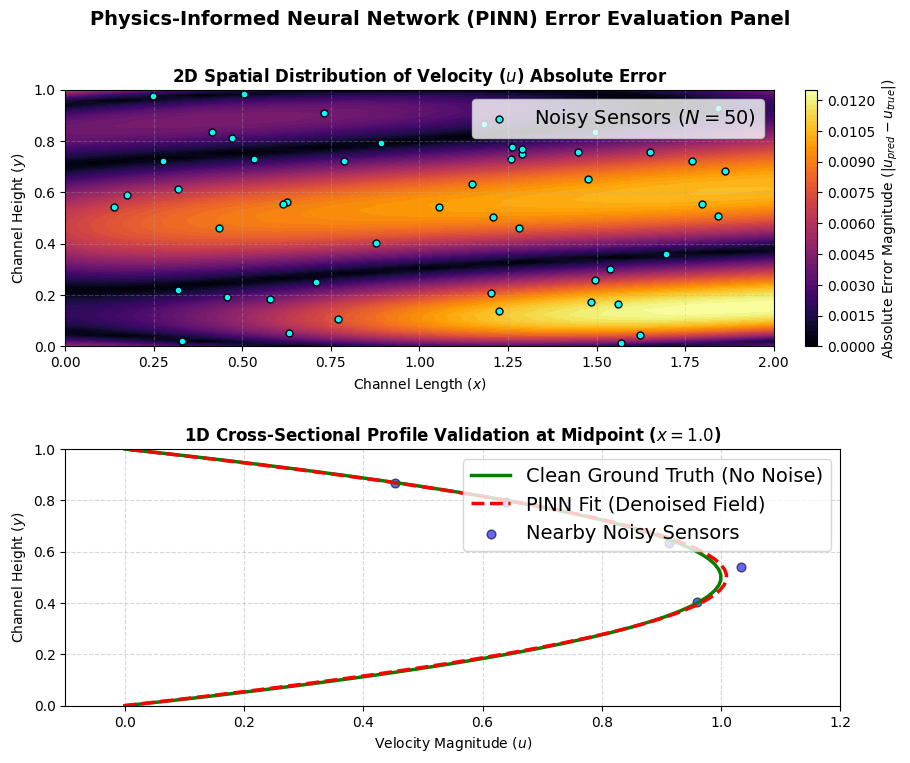

In [100]:
# ==============================================================================
# 9. PROFESSIONAL ERROR VISUALIZATION PLOTS
# ==============================================================================
import matplotlib.cm as cm

# Reshape the 5000 flat points back into a 2D spatial grid shape for heatmaps
abs_error_u_grid = abs_error_u.reshape(X.shape)
u_pred_grid = u_pred.reshape(X.shape)

# Create a clean dual-subplot workspace
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4)

# ------------------------------------------------------------------------------
# PANEL 1: 2D Spatial Contour Plot of Absolute Error
# ------------------------------------------------------------------------------
# This map identifies exactly where spatial distortions or gradient leaks occur
contour = ax1.contourf(X, Y, abs_error_u_grid, levels=50, cmap="inferno")
cbar = fig.colorbar(contour, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("Absolute Error Magnitude ($|u_{pred} - u_{true}|$)", fontsize=10)

# Overlay the 50 original noisy sensor locations to show data distribution density
ax1.scatter(sensor_cords[:, 0], sensor_cords[:, 1], color="cyan", s=25, 
            edgecolor="black", marker="o", label="Noisy Sensors ($N=50$)")

ax1.set_title("2D Spatial Distribution of Velocity ($u$) Absolute Error", fontsize=12, fontweight="bold")
ax1.set_xlabel("Channel Length ($x$)", fontsize=10)
ax1.set_ylabel("Channel Height ($y$)", fontsize=10)
ax1.set_xlim([0.0, L])
ax1.set_ylim([0.0, H])
ax1.legend(loc="upper right")
ax1.grid(True, linestyle="--", alpha=0.3)

# ------------------------------------------------------------------------------
# PANEL 2: 1D Cross-Sectional Verification Profile at Central Midpoint (x = 1.0)
# ------------------------------------------------------------------------------
# Extract a vertical slice at the center index along the x-axis
mid_x_idx = X.shape[1] // 2 
y_profile = Y[:, mid_x_idx]
u_pred_profile = u_pred_grid[:, mid_x_idx]
u_true_profile = 4.0 * y_profile * (1.0 - y_profile)

# Plot the smooth neural network prediction vs the clean true physics
ax2.plot(u_true_profile, y_profile, 'g-', linewidth=2.5, label="Clean Ground Truth (No Noise)")
ax2.plot(u_pred_profile, y_profile, 'r--', linewidth=2.5, label="PINN Fit (Denoised Field)")

# Project scattered sensor points located near the midpoint slice (e.g., 0.8 < x < 1.2)
mid_sensors_mask = (sensor_cords[:, 0] >= 0.8) & (sensor_cords[:, 0] <= 1.2)
if np.any(mid_sensors_mask):
    ax2.scatter(mock_u[mid_sensors_mask], sensor_cords[mid_sensors_mask, 1], 
                color="blue", alpha=0.6, s=40, edgecolor="black", label="Nearby Noisy Sensors")

ax2.set_title("1D Cross-Sectional Profile Validation at Midpoint ($x = 1.0$)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Velocity Magnitude ($u$)", fontsize=10)
ax2.set_ylabel("Channel Height ($y$)", fontsize=10)
ax2.set_xlim([-0.1, 1.2])
ax2.set_ylim([0.0, H])
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.5)

# Render and present the complete diagnostic layout board
plt.suptitle("Physics-Informed Neural Network (PINN) Error Evaluation Panel", fontsize=14, fontweight="bold")
plt.savefig("pinn_fluid_error_plots.png", dpi=300, bbox_inches='tight')
plt.show()


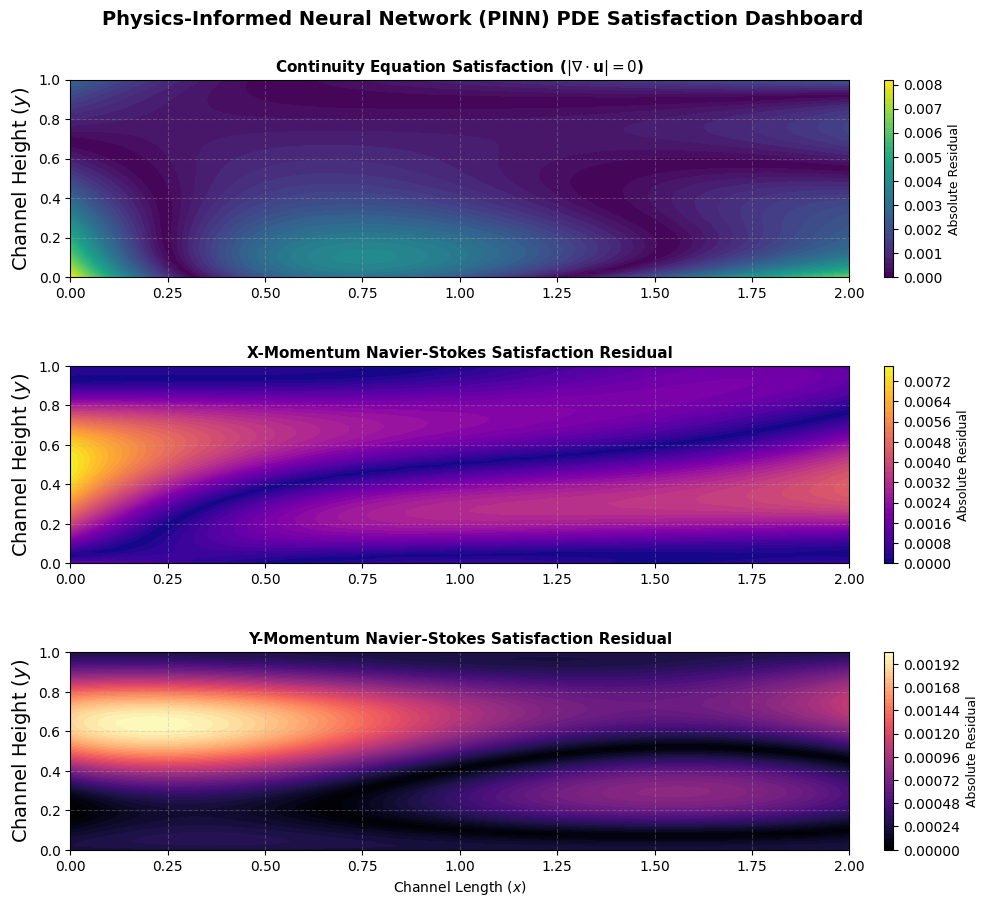


          PDE SATISFACTION SUMMARY             
Mean Continuity Residual: 1.1739e-03
Mean X-Momentum Residual:  1.8953e-03
Mean Y-Momentum Residual:  6.1004e-04


In [102]:
# ==============================================================================
# 10. PHYSICS SATISFACTION PLOTS (PDE RESIDUALS HABITAT)
# ==============================================================================
# Extract the raw partial differential equation residuals from DeepXDE
# navier_stokes_2d returns a list of 3 arrays: [continuity, momentum_x, momentum_y]
pde_residuals = model.predict(test_points, operator=navier_stokes_2d)

# Compute absolute values and reshape to the 2D evaluation grid
continuity_residual_grid = np.abs(pde_residuals[0]).reshape(X.shape)
momentum_x_residual_grid = np.abs(pde_residuals[1]).reshape(X.shape)
momentum_y_residual_grid = np.abs(pde_residuals[2]).reshape(X.shape)

# Create a clean vertical 3-panel figure layout
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 10))
plt.subplots_adjust(hspace=0.45)

# Panel 1: Continuity Equation Residual (|u_x + v_y|)
cf1 = ax1.contourf(X, Y, continuity_residual_grid, levels=50, cmap="viridis")
fig.colorbar(cf1, ax=ax1, fraction=0.046, pad=0.04).set_label("Absolute Residual", fontsize=9)
ax1.set_title("Continuity Equation Satisfaction ($|\\nabla \\cdot \\mathbf{u}| = 0$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Channel Height ($y$)")
ax1.grid(True, linestyle="--", alpha=0.3)

# Panel 2: X-Momentum Equation Residual
cf2 = ax2.contourf(X, Y, momentum_x_residual_grid, levels=50, cmap="plasma")
fig.colorbar(cf2, ax=ax2, fraction=0.046, pad=0.04).set_label("Absolute Residual", fontsize=9)
ax2.set_title("X-Momentum Navier-Stokes Satisfaction Residual", fontsize=11, fontweight="bold")
ax2.set_ylabel("Channel Height ($y$)")
ax2.grid(True, linestyle="--", alpha=0.3)

# Panel 3: Y-Momentum Equation Residual
cf3 = ax3.contourf(X, Y, momentum_y_residual_grid, levels=50, cmap="magma")
fig.colorbar(cf3, ax=ax3, fraction=0.046, pad=0.04).set_label("Absolute Residual", fontsize=9)
ax3.set_title("Y-Momentum Navier-Stokes Satisfaction Residual", fontsize=11, fontweight="bold")
ax3.set_xlabel("Channel Length ($x$)", fontsize=10)
ax3.set_ylabel("Channel Height ($y$)")
ax3.grid(True, linestyle="--", alpha=0.3)

# Add a comprehensive global dashboard banner
plt.suptitle("Physics-Informed Neural Network (PINN) PDE Satisfaction Dashboard", fontsize=14, fontweight="bold", y=0.95)

# Save high-resolution visualization output asset
plt.savefig("pinn_physics_satisfaction.png", dpi=300, bbox_inches='tight')
plt.show()

# Print quantitative summaries to the console terminal
print("\n" + "="*45)
print("          PDE SATISFACTION SUMMARY             ")
print("="*45)
print(f"Mean Continuity Residual: {np.mean(continuity_residual_grid):.4e}")
print(f"Mean X-Momentum Residual:  {np.mean(momentum_x_residual_grid):.4e}")
print(f"Mean Y-Momentum Residual:  {np.mean(momentum_y_residual_grid):.4e}")
print("="*45)


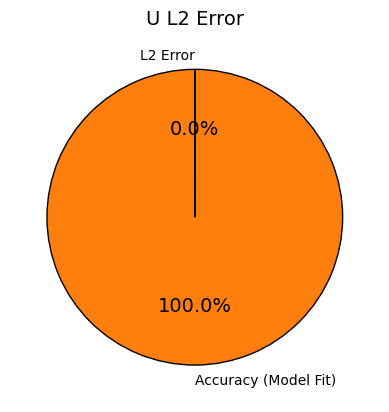

In [104]:
# l2_error_pct = 100 * np.linalg.norm(x_test - x_pred) / np.linalg.norm(x_test)
sizes = [l2_error_u, 100 - l2_error_u]
labels = ['L2 Error', 'Accuracy (Model Fit)']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
plt.title("U L2 Error")
plt.show()

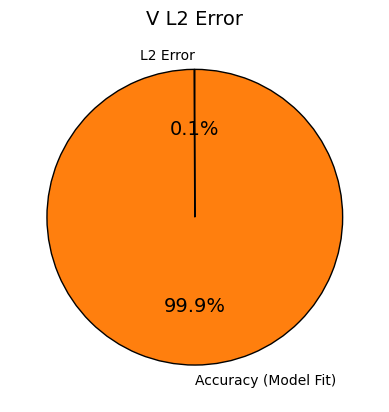

In [105]:
sizes = [l2_error_v, 100 - l2_error_v]
labels = ['L2 Error', 'Accuracy (Model Fit)']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
plt.title("V L2 Error")
plt.show()

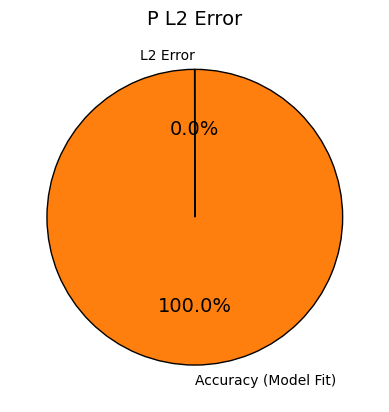

In [106]:
sizes = [l2_error_p, 100 - l2_error_p]
labels = ['L2 Error', 'Accuracy (Model Fit)']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
plt.title("P L2 Error")
plt.show()

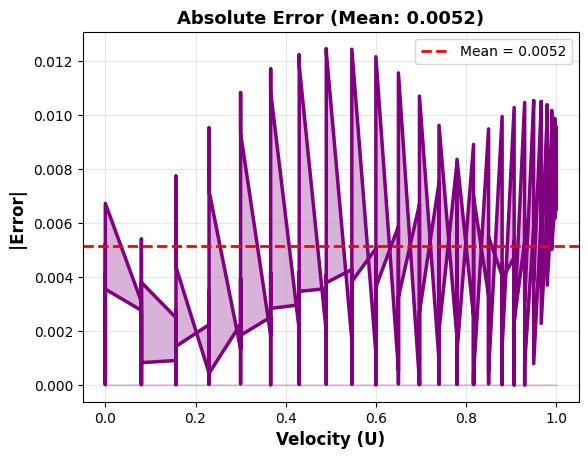

In [110]:
plt.plot(u_true, abs_error_u, color='purple', linewidth=2.5)
mean_abs_err_u = np.mean(abs_error_u)

plt.axhline(
    y=mean_abs_err_u, color='red', linestyle='--', linewidth=2,
    label=f'Mean = {mean_abs_err_u:.4f}'
)
plt.fill_between(u_true.flatten(), 0, abs_error_u.flatten(), alpha=0.3, color='purple')

plt.xlabel('Velocity (U)', fontsize=12, fontweight='bold')
plt.ylabel('|Error| ', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {mean_abs_err_u:.4f})', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

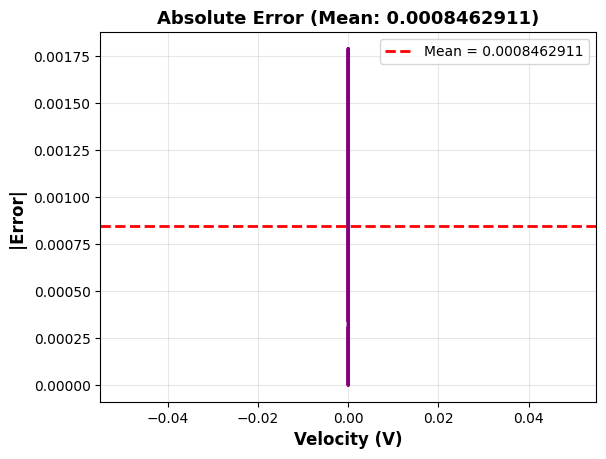

In [113]:
plt.plot(v_true, abs_error_v, color='purple', linewidth=2.5)
mean_abs_err_v = np.mean(abs_error_v)

plt.axhline(
    y=mean_abs_err_v, color='red', linestyle='--', linewidth=2,
    label=f'Mean = {mean_abs_err_v:.10f}'
)
plt.fill_between(v_true.flatten(), 0, abs_error_v.flatten(), alpha=0.3, color='purple')

plt.xlabel('Velocity (V)', fontsize=12, fontweight='bold')
plt.ylabel('|Error| ', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {mean_abs_err_v:.10f})', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

In [115]:
# 1. Group multiple coordinates into a single matrix row-by-row
custom_points = np.array([
    [0.5, 0.25],  # Point 1 (x, y)
    [1.0, 0.50],  # Point 2 (x, y)
    [1.5, 0.75]   # Point 3 (x, y)
]) # Shape: (3, 2)

# 2. Extract batch prediction arrays
batch_predictions = model.predict(custom_points) # Shape: (3, 3)

# 3. Extract matching columns
u_predictions = batch_predictions[:, 0] # Horizontal velocities for all points
v_predictions = batch_predictions[:, 1] # Vertical velocities for all points
p_predictions = batch_predictions[:, 2] # Pressures for all points

for i, pt in enumerate(custom_points):
    print(f"Point {i+1} at x={pt[0]}, y={pt[1]} -> u={u_predictions[i]:.4f},v={v_predictions[i]:.4f}, p={p_predictions[i]:.4f}")


Point 1 at x=0.5, y=0.25 -> u=0.7498,v=0.0014, p=0.1450
Point 2 at x=1.0, y=0.5 -> u=1.0094,v=0.0018, p=0.0983
Point 3 at x=1.5, y=0.75 -> u=0.7554,v=0.0011, p=0.0506
